In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import pearsonr

In [5]:
# ======================================================
# 1. LOAD DATA
# ======================================================

with open("../../data/raw/training/EXIST2026_training.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# ======================================================
# 2. CREATE A SIMPLE TABLE
# One row = one user viewing one meme
# ======================================================

rows = []

for meme_id, meme_data in data.items():

    # --------------------------------------------------
    # Example labels
    # Replace this with your actual labels
    # --------------------------------------------------

    labels = meme_data["labels_task2_1"]
    # example:
    # ["yes", "no", "yes", "yes", "no", "yes"]

    # yes ratio = number of yes / total votes
    yes_ratio = labels.count("YES") / len(labels)

    # physiological data
    modalities = meme_data["sensorial"]["modalities"]

    # collect all users
    users = set()

    for modality in modalities.values():
        users.update(modality["by_user"].keys())

    # create one row per user
    for user in users:

        row = {
            "meme_id": meme_id,
            "user": user,
            "yes_ratio": yes_ratio
        }

        # add all physiological features
        for modality_name, modality_data in modalities.items():

            if user not in modality_data["by_user"]:
                continue

            features = modality_data["by_user"][user]

            for feature_name, value in features.items():

                column_name = f"{modality_name}_{feature_name}"

                row[column_name] = value

        rows.append(row)

# convert to dataframe
df = pd.DataFrame(rows)

In [2]:
df.head()

,meme_id,user,yes_ratio,ET_reaction_time,ET_3d_eye_states_pupil diameter left [mm]_mean,ET_3d_eye_states_pupil diameter left [mm]_std,ET_3d_eye_states_pupil diameter left [mm]_max,ET_3d_eye_states_pupil diameter left [mm]_min,ET_3d_eye_states_pupil diameter right [mm]_mean,ET_3d_eye_states_pupil diameter right [mm]_std,...,EEG_EXG_Channel_14_Delta_power,EEG_EXG_Channel_14_Theta_power,EEG_EXG_Channel_14_Alpha_power,EEG_EXG_Channel_14_Beta_power,EEG_EXG_Channel_14_Gamma_power,EEG_EXG_Channel_15_Delta_power,EEG_EXG_Channel_15_Theta_power,EEG_EXG_Channel_15_Alpha_power,EEG_EXG_Channel_15_Beta_power,EEG_EXG_Channel_15_Gamma_power
0,110887,ES1,1.0,10080.0059,2.7610,0.1419,3.0798,1.7061,2.6514,0.2088,...,-3.0379,-3.3720,-3.1067,-2.1255,-1.9310,-3.0358,-3.3877,-3.0973,-2.3085,-1.8388
1,110887,ES2,1.0,16708.0000,3.6960,0.1528,4.1210,3.2277,3.5063,0.2394,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,110887,ES3,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.6632,-0.1452,-0.1111,0.3847,-0.1650,0.6314,-0.0105,0.0368,1.0030,0.2781
3,110466,ES1,0.5,23014.0000,2.7497,0.2256,4.2079,1.7904,2.5381,0.1771,...,-2.8040,-3.1027,-2.8525,-1.9516,-1.7911,-2.9836,-3.3187,-3.0321,-2.2938,-1.8278
4,110466,ES2,0.5,15835.0000,4.1436,0.1773,4.5619,3.4262,3.3358,0.2138,...,0.0741,-0.1058,-0.1275,-0.1567,-0.3260,0.1823,0.2024,0.2106,0.4890,0.1139


In [6]:
feature_cols = [
    c for c in df.columns
    if c not in ["meme_id", "user", "yes_ratio"]
]

# normalize user by user
for user in df["user"].unique():

    user_mask = df["user"] == user

    for col in feature_cols:

        # skip non-numeric columns
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue

        mean = df.loc[user_mask, col].mean()
        std = df.loc[user_mask, col].std()

        # avoid division by zero
        if std == 0 or pd.isna(std):
            continue

        df.loc[user_mask, col] = (
            (df.loc[user_mask, col] - mean) / std
        )

print("Normalization done.")

Normalization done.


In [7]:
numeric_df = df.select_dtypes(include=[np.number])

# Remove infinity values
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)

# Remove rows with missing values
numeric_df = numeric_df.dropna()

# OPTIONAL: make numbers smaller using normalization
numeric_df = (numeric_df - numeric_df.mean()) / numeric_df.std()

# Calculate correlation
correlation_matrix = numeric_df.corr()

print(correlation_matrix)

                                                yes_ratio  ET_reaction_time  \
yes_ratio                                        1.000000          0.101138   
ET_reaction_time                                 0.101138          1.000000   
ET_3d_eye_states_pupil diameter left [mm]_mean   0.008126          0.076943   
ET_3d_eye_states_pupil diameter left [mm]_std   -0.021215          0.257685   
ET_3d_eye_states_pupil diameter left [mm]_max    0.020515          0.234277   
...                                                   ...               ...   
EEG_EXG_Channel_15_Delta_power                   0.063451          0.044908   
EEG_EXG_Channel_15_Theta_power                   0.074129          0.051472   
EEG_EXG_Channel_15_Alpha_power                   0.055120          0.053991   
EEG_EXG_Channel_15_Beta_power                    0.031560          0.053041   
EEG_EXG_Channel_15_Gamma_power                   0.027034          0.046709   

                                                ET_

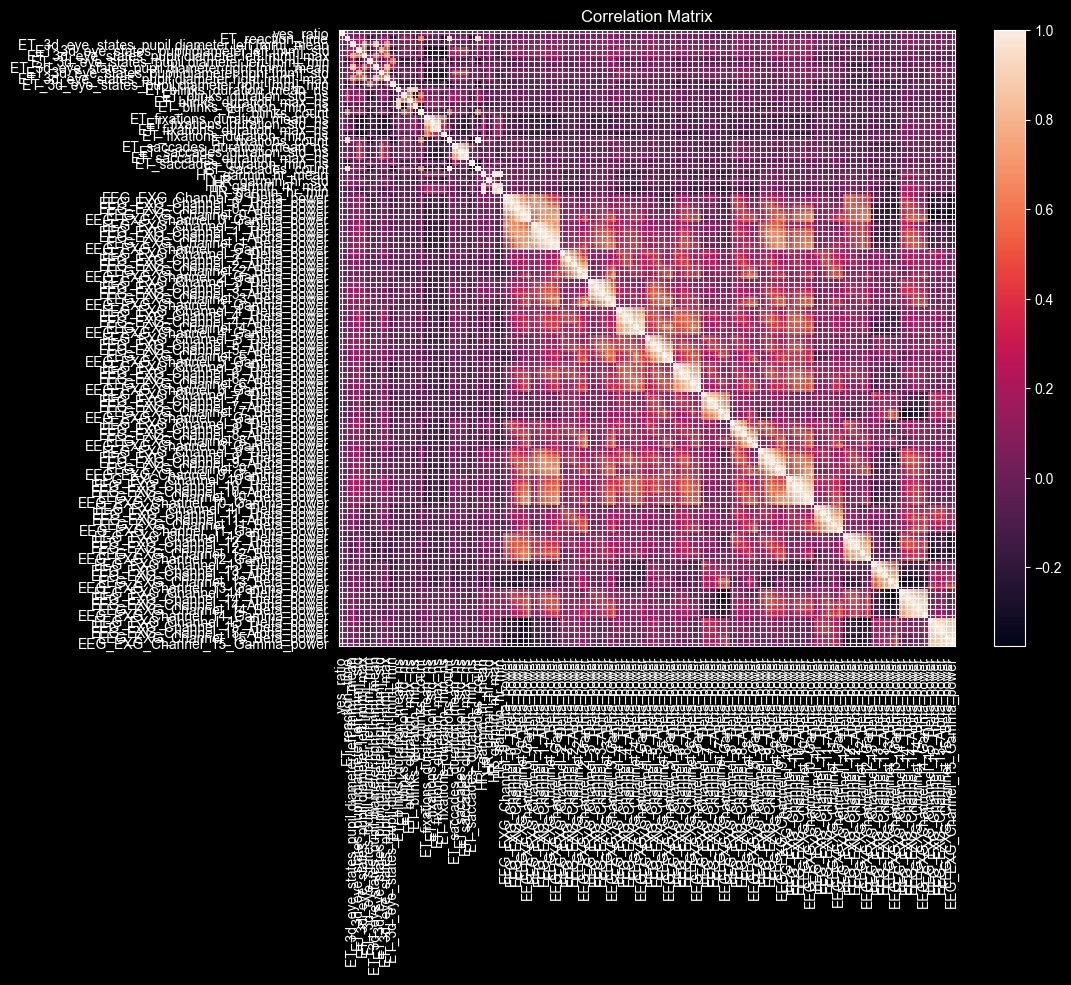

In [10]:
# Plot correlation matrix
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix)

# Add color bar
plt.colorbar()

# Add column names
plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns,
           rotation=90)

plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)

# Title
plt.title("Correlation Matrix")

# Show plot
plt.show()

In [ ]:
fig = px.imshow(
    correlation_matrix,
    text_auto=False,  # no numbers on cells
    color_continuous_scale="sunset",  # similar diverging style
    #zmin=-1, zmax=1   # keep correlation range fixed
)
#### 'aggrnyl', 'agsunset', 'algae', 'amp', 'armyrose', 'balance','blackbody', 'bluered', 'blues', 'blugrn', 'bluyl', 'brbg','brwnyl', 'bugn', 'bupu', 'burg', 'burgyl', 'cividis', 'curl','darkmint', 'deep', 'delta', 'dense', 'earth', 'edge', 'electric','emrld', 'fall', 'geyser', 'gnbu', 'gray', 'greens', 'greys','haline', 'hot', 'hsv', 'ice', 'icefire', 'inferno', 'jet','magenta', 'magma', 'matter', 'mint', 'mrybm', 'mygbm', 'oranges','orrd', 'oryel', 'oxy', 'peach', 'phase', 'picnic', 'pinkyl','piyg', 'plasma', 'plotly3', 'portland', 'prgn', 'pubu', 'pubugn','puor', 'purd', 'purp', 'purples', 'purpor', 'rainbow', 'rdbu','rdgy', 'rdpu', 'rdylbu', 'rdylgn', 'redor', 'reds', 'solar','spectral', 'speed', 'sunset', 'sunsetdark', 'teal', 'tealgrn','tealrose', 'tempo', 'temps', 'thermal', 'tropic', 'turbid','turbo', 'twilight', 'viridis', 'ylgn', 'ylgnbu', 'ylorbr','ylorrd'
# Remove axis labels (keep it clean)
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)

# Hover shows row/column + value automatically
fig.update_traces(
    hovertemplate="Row: %{y}<br>Column: %{x}<br>Correlation: %{z:.3f}<extra></extra>"
)

fig.update_layout(
    title="Correlation Matrix",
)

fig.write_html("correlation_plot.html")

In [11]:
# Create the interactive heatmap
fig = px.imshow(
    correlation_matrix,
    text_auto=False, # Set to True if you want values written on the cells
    aspect="auto",
    color_continuous_scale='RdBu_r', # Classic red-blue correlation scale
    title="Correlation Matrix"
)

# Update layout for better readability
fig.update_layout(
    width=800,
    height=800,
    xaxis_nticks=len(correlation_matrix.columns)
)
fig.write_html("correlation_plot.html")

In [ ]:
# Create the interactive heatmap
fig = px.imshow(
    correlation_matrix,
    # Custom color scale: 0 is Black, 1 is White
    color_continuous_scale=[[0, 'black'], [1, 'white']],
    range_color=[0, 1],
    title="Correlation Matrix"
)

# Force the background to be white and clean up the layout
fig.update_layout(
    width=700,
    height=700,
    xaxis_title=None,
    yaxis_title=None,
    paper_bgcolor='white',  # Background of the entire HTML component
    plot_bgcolor='white',   # Background of the plotting area
    margin=dict(l=20, r=20, t=50, b=20) # Tighten margins
)

# Remove the text labels from the rows and columns
fig.update_xaxes(showticklabels=False, showgrid=False, zeroline=False)
fig.update_yaxes(showticklabels=False, showgrid=False, zeroline=False)

fig.write_html("correlation_plot.html")


In [12]:
numeric_df = df.select_dtypes(include=[np.number])

# Clean data
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)
numeric_df = numeric_df.dropna()

# Correlation with target
correlation_with_target = numeric_df.corr()["yes_ratio"]

print(correlation_with_target)

yes_ratio                                         1.000000
ET_reaction_time                                  0.101138
ET_3d_eye_states_pupil diameter left [mm]_mean    0.008126
ET_3d_eye_states_pupil diameter left [mm]_std    -0.021215
ET_3d_eye_states_pupil diameter left [mm]_max     0.020515
                                                    ...   
EEG_EXG_Channel_15_Delta_power                    0.063451
EEG_EXG_Channel_15_Theta_power                    0.074129
EEG_EXG_Channel_15_Alpha_power                    0.055120
EEG_EXG_Channel_15_Beta_power                     0.031560
EEG_EXG_Channel_15_Gamma_power                    0.027034
Name: yes_ratio, Length: 109, dtype: float64


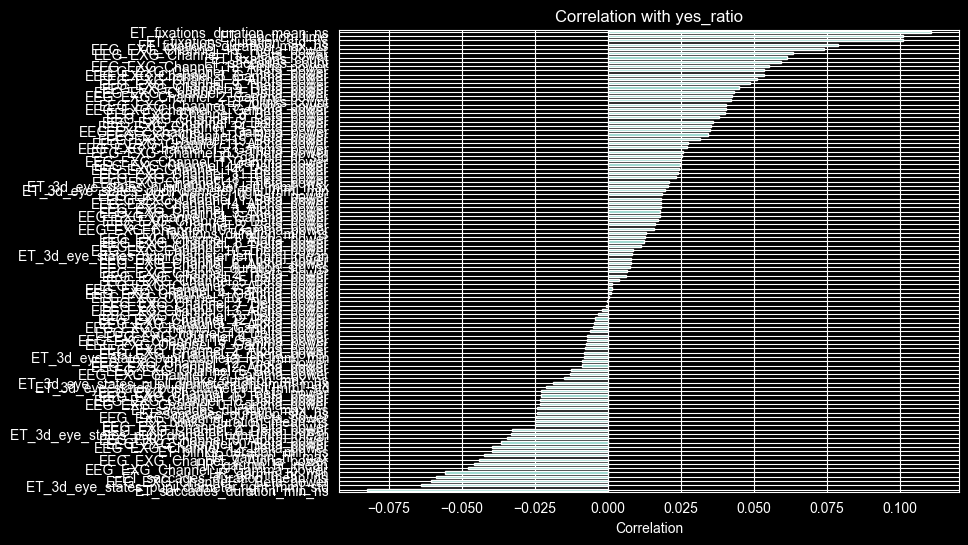

In [13]:
# Compute correlation with target
correlation_with_target = (
    numeric_df.corr()["yes_ratio"]
    .drop("yes_ratio")
)

# Sort correlations
correlation_with_target = correlation_with_target.sort_values()

# Create plot
plt.figure(figsize=(8, 6))

correlation_with_target.plot(kind="barh")

# Labels and title
plt.xlabel("Correlation")
plt.title("Correlation with yes_ratio")

# Show plot
plt.show()

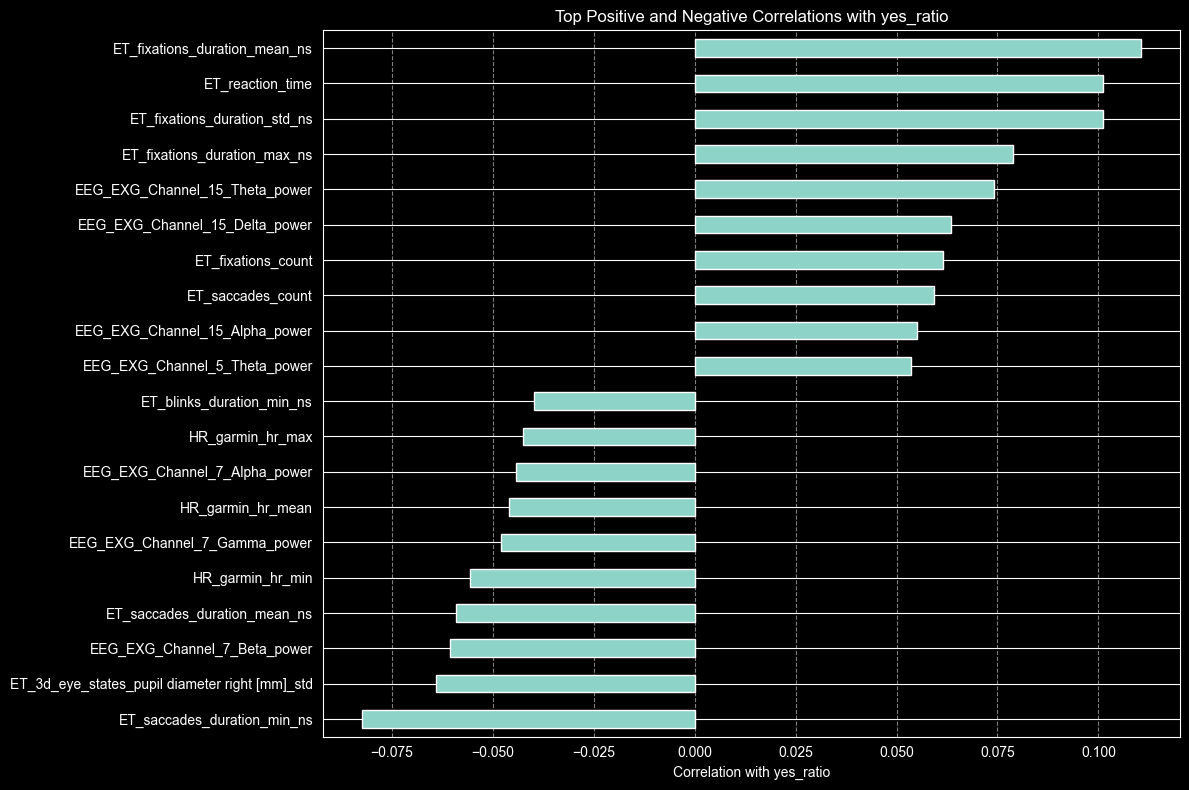

In [14]:
# Compute correlation with target
corr = (
    numeric_df.corr()["yes_ratio"]
    .drop("yes_ratio")
)

# Top 10 positive correlations
top_positive = corr.sort_values(ascending=False).head(10)

# Top 10 negative correlations
top_negative = corr.sort_values(ascending=True).head(10)

# Combine them
top_features = pd.concat([top_negative, top_positive])

# Plot
plt.figure(figsize=(12, 8))
top_features.sort_values().plot(kind="barh")

# Styling
plt.xlabel("Correlation with yes_ratio")
plt.title("Top Positive and Negative Correlations with yes_ratio")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()